# Overfitting and Regularization — Polynomial Regression
Demonstrating how high-degree polynomial models overfit, and how L2 regularization (Ridge) controls it.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

## Cost Function
Mean squared error cost for linear regression.

In [281]:
def compute_cost(x, y, w, b):
    f_wb = np.dot(x,w) + b
    cost = (f_wb - y)**2
    total_cost = cost.mean()/2
    return total_cost

## Gradient Function
Computes gradients of cost w.r.t weights and bias using vectorized operations.

In [282]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    f_wb = np.dot(x,w) + b
    error = f_wb - y
    dj_dw = x.T @ error
    dj_dw = dj_dw/m
    dj_db = error.mean()
    return dj_dw, dj_db

## Gradient Descent
General purpose gradient descent loop. Accepts any cost and gradient function — used for both overfit and regularized models.

In [283]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_func, gradient_func):
    w = copy.deepcopy(w_in)
    b = b_in
    j_history = []
    for i in range(num_iter):
        dj_dw, dj_db = gradient_func(x, y, w, b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<(1000000):
            j_history.append(cost_func(x,y,w,b))

        if i% math.ceil(num_iter / 10)==0:
            print(f"Iteration: {i:<8} cost:{j_history[-1]:12.6f}")

    return w,b, j_history
  

## Training Data
6 data points simulating house size vs price. Few points intentionally — makes overfitting easier to trigger.

In [284]:
X_train = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y_train = np.array([1.5, 6.0, 2.8, 6.1, 1.0, 7.9]) 


## Feature Engineering + Normalization
Expanding X to degree 10 polynomial features (x¹ to x¹⁰). Normalizing to prevent large values from dominating gradient updates.

In [285]:
X_poly = np.hstack([X_train**i for i in range(1,11)])
mu = X_poly.mean(axis=0)
sigma = X_poly.std(axis=0)
X_norm1 = (X_poly - mu) / sigma

## Training — Overfit Model
High degree features with no penalty on weight size. Model will fit training points closely but generalize poorly.

In [286]:
initial_w = np.zeros_like(X_poly[0])
initial_b = 0
alpha = 1e-1
iterations = 100000
w_overfit, b_overfit, cost = gradient_descent(X_norm1, y_train, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)

Iteration: 0        cost:    9.713442
Iteration: 10000    cost:    1.107797
Iteration: 20000    cost:    1.085869
Iteration: 30000    cost:    1.067584
Iteration: 40000    cost:    1.050487
Iteration: 50000    cost:    1.033904
Iteration: 60000    cost:    1.017649
Iteration: 70000    cost:    1.001667
Iteration: 80000    cost:    0.985942
Iteration: 90000    cost:    0.970464


In [287]:
x_plot = np.linspace(1,6,300).reshape(-1,1)
X_norm2 = np.hstack([x_plot**i for i in range(1,11)])
X_norm2 = (X_norm2 - mu) / sigma
y_overfit = np.dot(X_norm2, w_overfit) + b_overfit

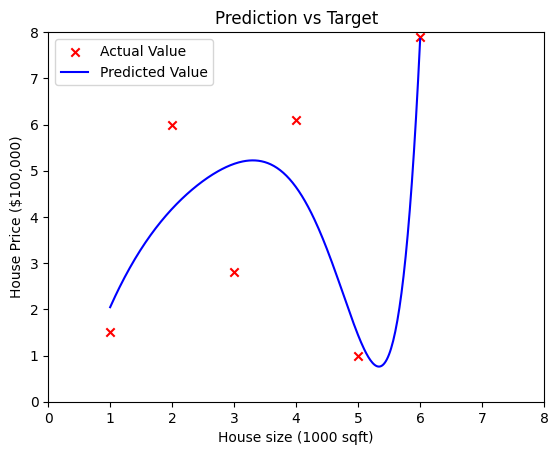

In [288]:
plt.scatter(X_train, y_train , marker='x', c='r', label='Actual Value'); plt.title("Prediction vs Target")
plt.plot(x_plot, y_overfit, c='b', label='Predicted Value'); plt.xlabel('House size (1000 sqft)'); plt.ylabel('House Price ($100,000)')
plt.axis([0,8,0,8])
plt.legend()
plt.show()

## Regularized Cost Function
Adds L2 penalty (sum of squared weights) to the cost. Forces weights to stay small, reducing model complexity.

In [289]:
def reg_cost(X, y, w, b, lambda_ = 1):

    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    err = (f_wb - y)**2
    cost = err.sum()/ (2*m)
    w_cost = ((w**2).sum()) * (lambda_ / (2*m))
    total_cost = cost + w_cost
    return total_cost

## Regularized Gradient
Gradient now includes the regularization term λ/m * w, which shrinks weights at each update step.

In [290]:
def reg_gradient_descent(X, y, w, b, lambda_ =  1):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    err = (f_wb - y)
    reg_gd = lambda_/m * w
    dj_dw = (X.T @ err)/m + reg_gd
    dj_db = err.sum() /m
    return dj_dw, dj_db

## Training — Regularized Model
Same setup but using regularized cost and gradient. lambda_ controls the strength of the penalty.

In [291]:
initial_w = np.zeros_like(X_poly[0])
initial_b = 0
alpha = 1e-2
iterations = 10000
w_regularized, b_regularized, cost = gradient_descent(X_norm1, y_train, initial_w, initial_b, alpha, iterations, reg_cost, reg_gradient_descent)

Iteration: 0        cost:   11.902148
Iteration: 1000     cost:    2.275760
Iteration: 2000     cost:    2.272437
Iteration: 3000     cost:    2.272364
Iteration: 4000     cost:    2.272362
Iteration: 5000     cost:    2.272362
Iteration: 6000     cost:    2.272362
Iteration: 7000     cost:    2.272362
Iteration: 8000     cost:    2.272362
Iteration: 9000     cost:    2.272362


In [292]:
x_plot = np.linspace(1,6,300).reshape(-1,1)
X_norm2 = np.hstack([x_plot**i for i in range(1,11)])
X_norm2 = (X_norm2 - mu) / sigma
y_reg = np.dot(X_norm2, w_regularized) + b_regularized
plots = [y_overfit, y_reg]

## Weight Comparison
Regularized weights should be visibly smaller in magnitude than overfit weights.

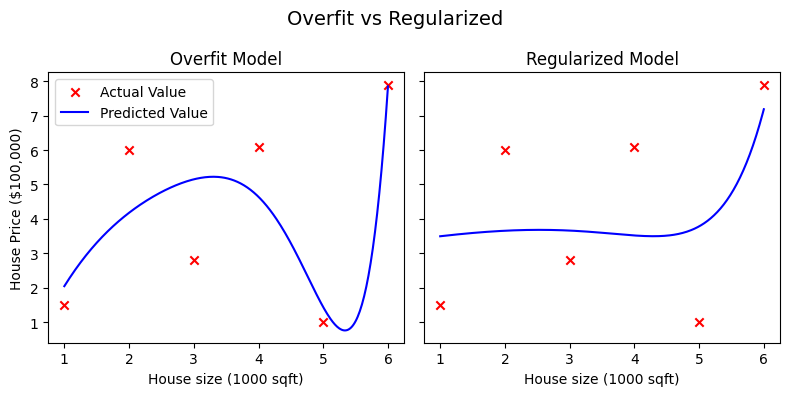

In [293]:
fig, ax = plt.subplots(1,2, figsize=(8,4), sharey = True)

for i in range(len(ax)):
    ax[i].scatter(X_train, y_train , marker='x', c='r', label='Actual Value')
    ax[i].plot(x_plot, plots[i], c='b', label='Predicted Value')
    ax[i].set_xlabel("House size (1000 sqft)")

ax[0].set_title("Overfit Model")
ax[1].set_title("Regularized Model")
ax[0].set_ylabel("House Price ($100,000)")
ax[0].legend()

fig.suptitle("Overfit vs Regularized", fontsize=14)

plt.tight_layout()
plt.show()

## Weight Comparison
Regularized weights should be visibly smaller in magnitude than overfit weights.

In [ ]:
print(f"w_overfit:{w_overfit}\nw_final:{w_regularized}")

w_overfit:[  9.59474585 -18.25174373   6.73943296  13.123316     1.68293353
 -11.59734586 -16.708822   -11.05498015   3.79014512  24.8332694 ]
w_final:[ 0.47189612 -0.23943473 -0.45782349 -0.40457799 -0.22770145 -0.00332067
  0.23094796  0.45633799  0.6637406   0.84933688]
